# Stage 1: Data Understanding

This notebook validates the runtime data acquisition layer for Phase 1. It downloads data directly from Yahoo Finance, inspects adjusted close prices and volume, checks missing values, and visualizes the sample asset universe.

## Objectives

- Use the `YahooFinanceProvider` directly at runtime.
- Download the sample universe: `HDFCBANK.NS`, `TCS.NS`, `GOLDBEES.NS`.
- Validate dates, adjusted close coverage, volume coverage, and missing values.
- Produce in-memory outputs: `prices_df` and `volume_df`.
- Visualize price behavior and data completeness before moving to returns.

In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_pipeline import SAMPLE_UNIVERSE, YahooFinanceProvider, build_data_inspection_table

In [12]:
symbols = list(SAMPLE_UNIVERSE)
start_date = "2015-01-01"
end_date = "2024-12-31"

provider = YahooFinanceProvider()
market_data = provider.get_market_data(symbols, start_date, end_date)

prices_df = market_data.prices_df
volume_df = market_data.volume_df
inspection_df = build_data_inspection_table(market_data)

print(f"Price field used: {market_data.price_field}")
print(f"Price shape: {prices_df.shape}")
print(f"Volume shape: {volume_df.shape}")

Price field used: Adj Close
Price shape: (2466, 3)
Volume shape: (2466, 3)


In [13]:
prices_df.head()

Ticker,GOLDBEES.NS,HDFCBANK.NS,TCS.NS
Date,,,
2015-01-01,24.563499,217.235352,975.650513
2015-01-02,24.511999,220.258667,988.643921
2015-01-05,24.662001,218.399063,973.619568
2015-01-06,24.979000,214.999237,937.725586
2015-01-07,25.021999,215.626724,926.648987


In [14]:
volume_df.head()

Ticker,GOLDBEES.NS,HDFCBANK.NS,TCS.NS
Date,,,
2015-01-01,983500,3544940,366830
2015-01-02,687400,5900384,925740
2015-01-05,1520600,4796000,1754242
2015-01-06,3063100,8219680,2423784
2015-01-07,2309100,5746112,2636332


In [15]:
inspection_df

,price_field,start_date,end_date,price_observations,volume_observations,missing_prices,missing_volume,dates_monotonic_increasing
symbol,,,,,,,,
GOLDBEES.NS,Adj Close,2015-01-01,2024-12-30,2466,2466,0,0,True
HDFCBANK.NS,Adj Close,2015-01-01,2024-12-30,2466,2466,0,0,True
TCS.NS,Adj Close,2015-01-01,2024-12-30,2466,2466,0,0,True


In [16]:
prices_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
GOLDBEES.NS,2466.0,37.241697,11.673048,0.335500,26.789000,34.790001,44.577501,67.019997
HDFCBANK.NS,2466.0,542.597168,197.967377,214.999237,388.714149,537.522888,720.424377,923.393494
TCS.NS,2466.0,2088.530693,1002.215559,832.824341,1019.353134,1803.354004,2991.327087,4253.906250


In [17]:
volume_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
GOLDBEES.NS,2466.0,3.446093e+06,4.741440e+06,0.0,1245700.00,2309682.5,4200318.25,166442200.0
HDFCBANK.NS,2466.0,1.760316e+07,2.182139e+07,570008.0,6174939.50,11538110.0,22169792.00,445342100.0
TCS.NS,2466.0,2.669150e+06,2.390096e+06,86822.0,1639957.75,2212441.0,3090992.50,88067154.0


In [18]:
missing_summary = pd.concat(
    [prices_df.isna().sum().rename("missing_prices"), volume_df.isna().sum().rename("missing_volume")],
    axis=1,
)
missing_summary

,missing_prices,missing_volume
Ticker,,
GOLDBEES.NS,0,0
HDFCBANK.NS,0,0
TCS.NS,0,0


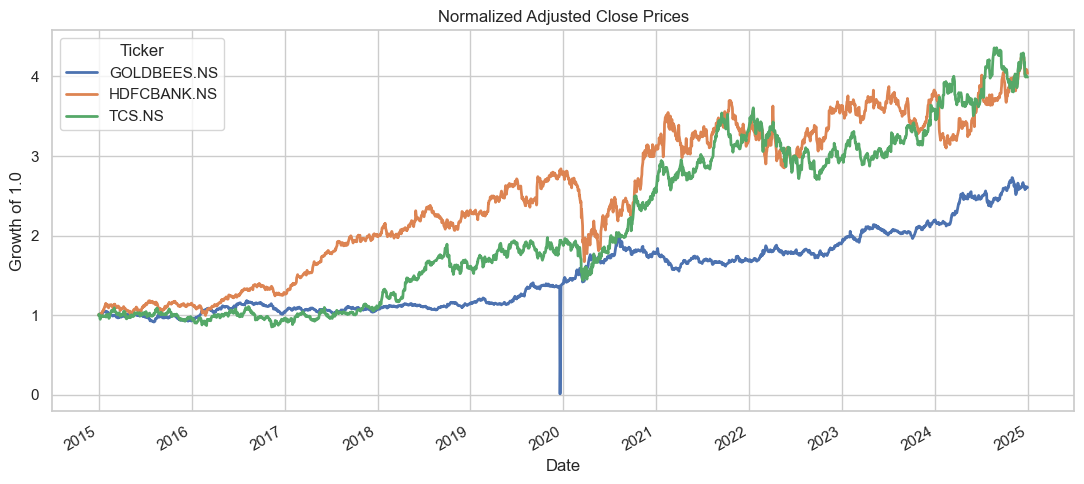

In [19]:
sns.set_theme(style="whitegrid")
normalized_prices = prices_df / prices_df.iloc[0]
ax = normalized_prices.plot(figsize=(11, 5), linewidth=2)
ax.set_title("Normalized Adjusted Close Prices")
ax.set_ylabel("Growth of 1.0")
ax.set_xlabel("Date")
plt.tight_layout()

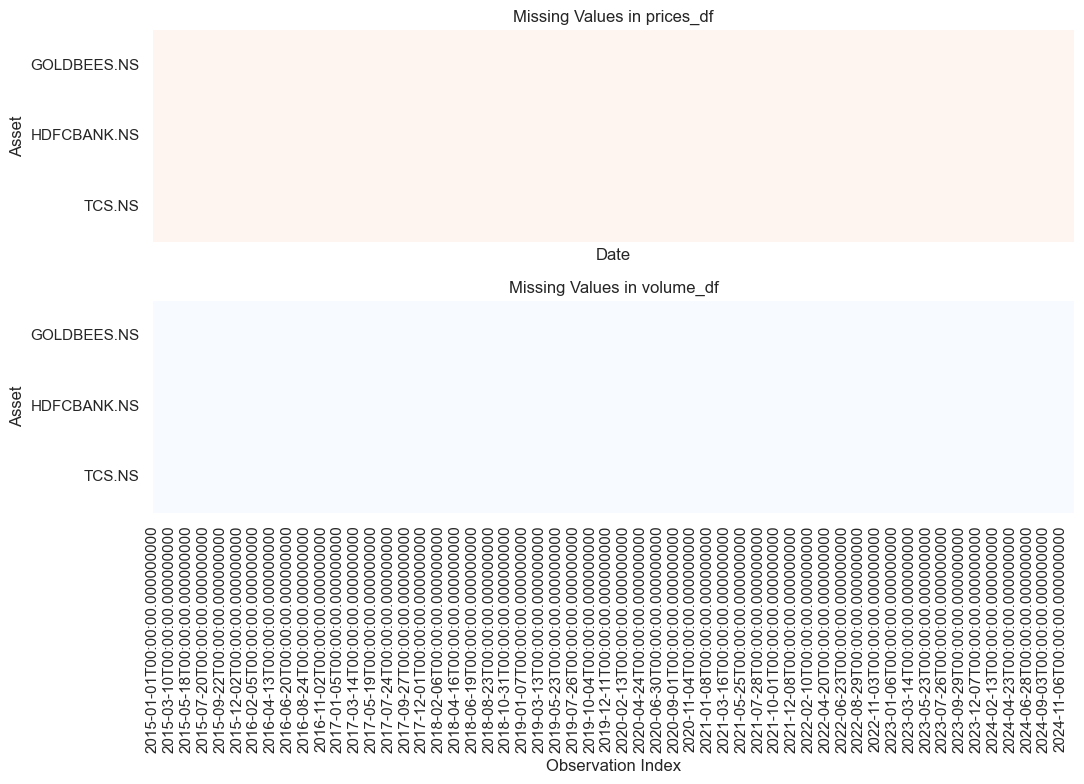

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
prices_df.isna().astype(int).T.pipe(sns.heatmap, cmap="Reds", cbar=False, ax=axes[0])
axes[0].set_title("Missing Values in prices_df")
axes[0].set_ylabel("Asset")

volume_df.isna().astype(int).T.pipe(sns.heatmap, cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("Missing Values in volume_df")
axes[1].set_ylabel("Asset")
axes[1].set_xlabel("Observation Index")
plt.tight_layout()

## Interpretation

- `prices_df` is the adjusted close panel used for downstream return calculations.
- `volume_df` helps validate tradability and data completeness before portfolio construction.
- Any missing-value clusters should be handled before returns are computed in Stage 2.
- This stage deliberately keeps all processing in memory and avoids persistent dataset storage.